# Importing Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pillow_heif
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from collections import Counter
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from PIL import Image


# Loading the images

In [ ]:


# Register HEIF opener with Pillow
pillow_heif.register_heif_opener()

# === Main dataset folder ===
dataset_path = "/Users/abdulmateen/Downloads/veggie copy"
target_size = (224, 224)

images = []
labels = []
class_names = []

# Map folder names to integer labels
label_map = {}
label_counter = 0

# Loop through each subfolder
for folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, folder)
    
    if os.path.isdir(folder_path):
        print(f"Loading class '{folder}' as label {label_counter}")
        label_map[folder] = label_counter
        class_names.append(folder)
        
        for filename in os.listdir(folder_path):
            # Updated to include HEIC files (case-insensitive)
            if filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.heic')):
                img_path = os.path.join(folder_path, filename)
                try:
                    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
                    img_array = tf.keras.preprocessing.image.img_to_array(img)
                    images.append(img_array)
                    labels.append(label_counter)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
        
        label_counter += 1

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Loaded", len(images), "images from", len(label_map), "classes.")
print("Classes:", label_map)

Loading class 'Bitterleaf' as label 0
Loading class 'Efirin' as label 1
Loading class 'Ewedu' as label 2
Loading class 'amunututu' as label 3
Loading class 'elegede' as label 4
Loading class 'soko ' as label 5
Loading class 'tete ' as label 6
Loading class 'ugu ' as label 7
Loading class 'uziza leave' as label 8
Loading class 'waterleaf' as label 9
Error loading /Users/abdulmateen/Downloads/veggie copy/waterleaf/IMG_1432.HEIC: Decoder plugin generated an error: Unexpected end of file
Loaded 3349 images from 10 classes.
Classes: {'Bitterleaf': 0, 'Efirin': 1, 'Ewedu': 2, 'amunututu': 3, 'elegede': 4, 'soko ': 5, 'tete ': 6, 'ugu ': 7, 'uziza leave': 8, 'waterleaf': 9}


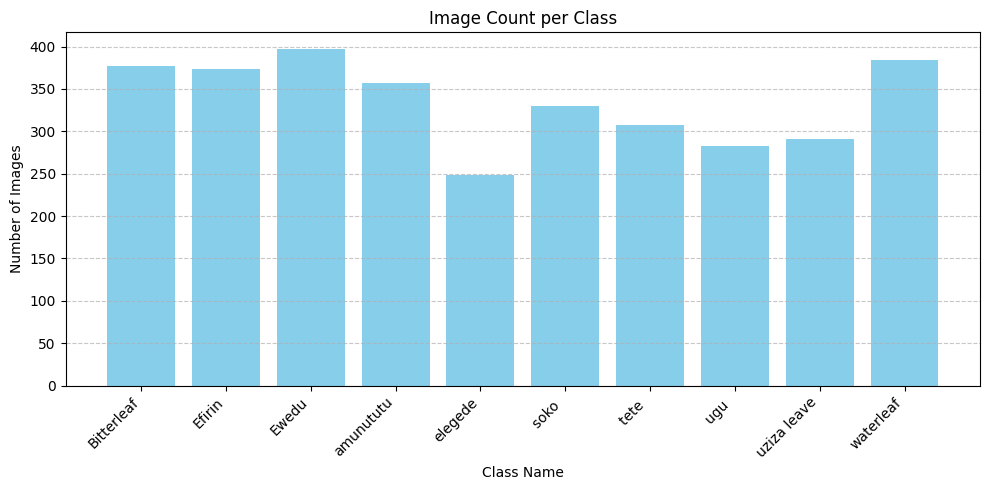

In [ ]:
# Count occurrences of each label
label_counts = Counter(labels)

# Map back to class names
class_labels = [class_names[i] for i in label_counts.keys()]
counts = [label_counts[i] for i in label_counts.keys()]

# Plot
plt.figure(figsize=(10, 5))
plt.bar(class_labels, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title("Image Count per Class")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [4]:
# images = images / 255.0  # Normalize



# 1. Split into train+val and test (80% train+val, 20% test)
train_val_images, test_images, train_val_labels, test_labels = train_test_split(
    images, labels, test_size=0.1, random_state=42, stratify=labels
)

# 2. Split train_val into train and val (e.g., 80% train, 20% val of the 80%)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_val_images, train_val_labels, test_size=0.1, random_state=42, stratify=train_val_labels
)

print("Train:", len(train_images))
print("Validation:", len(val_images))
print("Test:", len(test_images))




Train: 2712
Validation: 302
Test: 335


# TRAINING WITH RESNET

In [ ]:


# Define number of classes
num_classes = 10  # Replace with your actual number of classes

# Input layer
inputs = keras.Input(shape=(224, 224, 3))

# Rescale input images (optional – handled in data augmentation pipeline)
x = layers.Rescaling(1./255)(inputs)
# x = inputs  # Use input directly if rescaling is done elsewhere

# Load base model
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model

# Pass through base model
x = base_model(x, training=False)

# Add pooling, dropout, and final dense layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
#  kernel_regularizer=tf.keras.regularizers.l2(0.001)
# Build model
model1 = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model1.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model1.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,616,394 (90.09 MB)

 Trainable params: 24,586 (96.04 KB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    validation_split=0.2
)

train_generator = datagen.flow(
    train_images, train_labels,
    subset='training',
    batch_size=32
)

val_generator = datagen.flow(
    val_images, val_labels,
    subset='validation',
    batch_size=32
)




In [ ]:


# Define the early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',     # you can also use 'val_accuracy'
    patience=3,             # number of epochs to wait before stopping
    restore_best_weights=True,  # restores weights from best epoch
    verbose=1
)


In [49]:
history1 = model1.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=20,
    verbose=1,
    callbacks=[early_stop],
    batch_size=32
)
# history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=10,
#     callbacks=[early_stop],
#     steps_per_epoch=len(train_generator),
#     validation_steps=len(val_generator)
# )


Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.3384 - loss: 1.9708 - val_accuracy: 0.2483 - val_loss: 2.3779
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.6923 - loss: 1.0851 - val_accuracy: 0.2649 - val_loss: 2.0501
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.7435 - loss: 0.8751 - val_accuracy: 0.5364 - val_loss: 1.7334
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7812 - loss: 0.7489 - val_accuracy: 0.6722 - val_loss: 1.4314
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7917 - loss: 0.6976 - val_accuracy: 0.7881 - val_loss: 1.1246
Epoch 6/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8098 - loss: 0.6585 - val_accuracy: 0.8543 - val_loss: 0.8399
Epoch 7/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8378 - loss: 0.5736 - val_accuracy: 0.8742 - val_loss: 0.6402
Epoch 8/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.8405 - loss: 0.5767 - val_accuracy: 0.8974 - val_loss

In [ ]:
# Unfreeze last part of base model
base_model.trainable = True
fine_tune_at = 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,
    mode='min',             # fix: use mode, not model
    verbose=1
)

fine_tune_history1 = model1.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=3,
    verbose=1,
    callbacks=[checkpoint],
    batch_size=32
)
# fine_tune_history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=8,
#     verbose=1,
#     callbacks=[early_stop],
#     steps_per_epoch=len(train_images) // 32,
# )


Epoch 1/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9737 - loss: 0.1110
Epoch 1: val_loss improved from inf to 0.09307, saving model to best_model.h5


85/85 ━━━━━━━━━━━━━━━━━━━━ 388s 4s/step - accuracy: 0.9737 - loss: 0.1111 - val_accuracy: 0.9801 - val_loss: 0.0931
Epoch 2/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9754 - loss: 0.0856
Epoch 2: val_loss did not improve from 0.09307
85/85 ━━━━━━━━━━━━━━━━━━━━ 369s 4s/step - accuracy: 0.9754 - loss: 0.0859 - val_accuracy: 0.9801 - val_loss: 0.1449
Epoch 3/3
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9789 - loss: 0.0678
Epoch 3: val_loss did not improve from 0.09307
85/85 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.9789 - loss: 0.0677 - val_accuracy: 0.9801 - val_loss: 0.0955


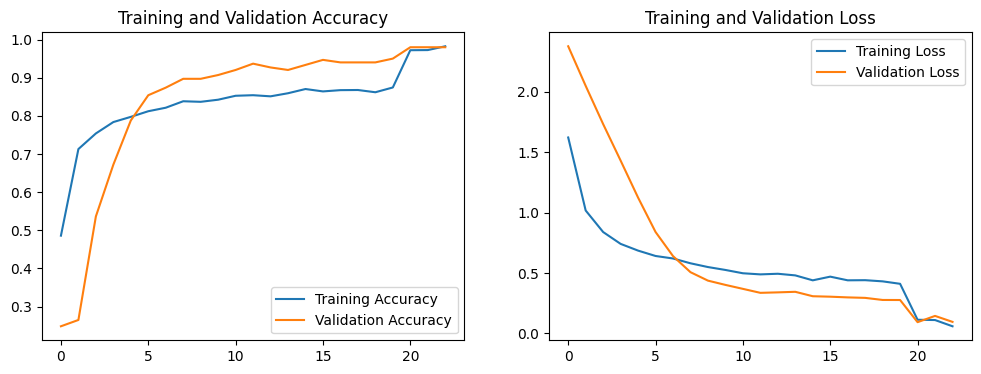

In [58]:
acc = history1.history['accuracy'] + fine_tune_history1.history['accuracy']
val_acc = history1.history['val_accuracy'] + fine_tune_history1.history['val_accuracy']
loss = history1.history['loss'] + fine_tune_history1.history['loss']
val_loss = history1.history['val_loss'] + fine_tune_history1.history['val_loss']

# acc = history1.history['accuracy'] 
# val_acc = history1.history['val_accuracy'] 
# loss = history1.history['loss'] 
# val_loss = history1.history['val_loss'] 


# acc =  fine_tune_history1.history['accuracy']
# val_acc = fine_tune_history1.history['val_accuracy']
# loss =  fine_tune_history1.history['loss']
# val_loss =  fine_tune_history1.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [9]:
model1.save('faruqres3000.h5')

In [ ]:

m1 = '/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/faruq1.h5'
m2 = '/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/faruqres3000.h5'
m3 = '/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/best_model1.h5'
model1 = tf.keras.models.load_model(m3)
# Register HEIF opener with Pill2w
pillow_heif.register_heif_opener()

def predict_single_image(model, image_path, class_names, target_size=(224, 224), show_image=True):
    """
    Make prediction on a single external image
    
    Args:
        model: Your trained Keras model
        image_path: Path to the image file
        class_names: List of class names (same order as training)
        target_size: Input size expected by model (224, 224)
        show_image: Whether to display the image
    
    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score (0-1)
        all_predictions: Array of all class probabilities
    """
    try:
        # Load and preprocess the image
        img = Image.open(image_path)
        
        # Convert to RGB if needed (handles HEIC, PNG with transparency, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Resize to target size
        img = img.resize(target_size)
        
        # Convert to numpy array
        img_array = np.array(img)
        
        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        
        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx]
        predicted_class = class_names[predicted_class_idx]
        
        # Display the image if requested
        if show_image:
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f'Prediction: {predicted_class} (Confidence: {confidence:.2%})')
            plt.axis('off')
            plt.show()
        
        return predicted_class, confidence, predictions[0]
        
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None, None, None

def predict_multiple_images(model, image_folder, class_names, target_size=(224, 224), show_results=True):
    """
    Make predictions on multiple images in a folder
    
    Args:
        model: Your trained Keras model
        image_folder: Path to folder containing images
        class_names: List of class names
        target_size: Input size expected by model
        show_results: Whether to display results
    
    Returns:
        results: List of dictionaries with results for each image
    """
    results = []
    
    # Get all image files in the folder
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.heic')
    image_files = [f for f in os.listdir(image_folder) 
                   if f.lower().endswith(image_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for i, filename in enumerate(image_files):
        image_path = os.path.join(image_folder, filename)
        print(f"\nProcessing {i+1}/{len(image_files)}: {filename}")
        
        predicted_class, confidence, all_predictions = predict_single_image(
            model, image_path, class_names, target_size, show_image=show_results
        )
        
        if predicted_class is not None:
            result = {
                'filename': filename,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'all_predictions': all_predictions
            }
            results.append(result)
            
            print(f"Prediction: {predicted_class} (Confidence: {confidence:.2%})")
        else:
            print(f"Failed to process {filename}")
    
    return results

def show_top_predictions(predictions, class_names, top_n=3):
    """
    Display top N predictions with their probabilities
    
    Args:
        predictions: Array of prediction probabilities
        class_names: List of class names
        top_n: Number of top predictions to show
    """
    # Get indices of top predictions
    top_indices = np.argsort(predictions)[::-1][:top_n]
    
    print(f"\nTop {top_n} predictions:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. {class_names[idx]}: {predictions[idx]:.2%}")

# Example usage functions
def predict_with_your_model(image_path):
    """
    Wrapper function using your specific model and class names
    """
    # Your class names from the training
    class_names = ['Bitterleaf', 'Efirin', 'Ewedu', 'amunututu', 'elegede', 
                   'soko ', 'tete ', 'ugu ', 'uziza leave', 'waterleaf']
    
    # Make prediction
    predicted_class, confidence, all_predictions = predict_single_image(
        model1, image_path, class_names, target_size=(224, 224), show_image=True
    )
    
    if predicted_class is not None:
        print(f"\nPredicted class: {predicted_class}")
        print(f"Confidence: {confidence:.2%}")
        
        # Show top 3 predictions
        show_top_predictions(all_predictions, class_names, top_n=3)
    
    return predicted_class, confidence, all_predictions

# Example usage:
# predicted_class, confidence, all_predictions = predict_with_your_model('/path/to/your/image.jpg')

# For batch processing:
# results = predict_multiple_images(model, '/path/to/image/folder', class_names)

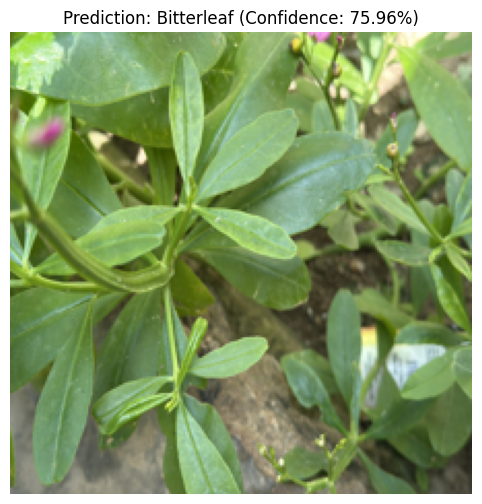


Predicted class: Bitterleaf
Confidence: 75.96%

Top 3 predictions:
1. Bitterleaf: 75.96%
2. waterleaf: 20.16%
3. Efirin: 3.65%


In [67]:
predicted_class, confidence, all_predictions = predict_with_your_model('/Users/abdulmateen/Downloads/vegetables/Waterleaf/IMG_6763.JPG')


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step 


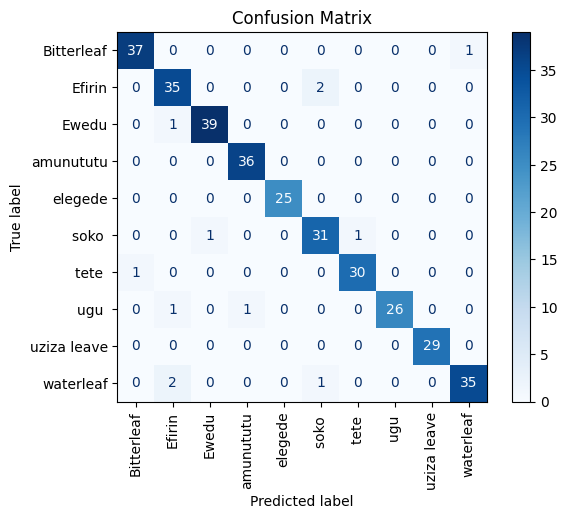

In [ ]:

def plot_confusion_matrix(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    y_pred_labels = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation='vertical', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()


plot_confusion_matrix(model1, test_images, test_labels, class_names)


In [ ]:

def print_classification_report(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    y_pred_labels = y_pred.argmax(axis=1)
    
    print(classification_report(y_test, y_pred_labels, target_names=class_names))


In [63]:

print_classification_report(model1, test_images, test_labels, class_names)


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
              precision    recall  f1-score   support

  Bitterleaf       0.97      0.97      0.97        38
      Efirin       0.90      0.95      0.92        37
       Ewedu       0.97      0.97      0.97        40
   amunututu       0.97      1.00      0.99        36
     elegede       1.00      1.00      1.00        25
       soko        0.91      0.94      0.93        33
       tete        0.97      0.97      0.97        31
        ugu        1.00      0.93      0.96        28
 uziza leave       1.00      1.00      1.00        29
   waterleaf       0.97      0.92      0.95        38

    accuracy                           0.96       335
   macro avg       0.97      0.97      0.97       335
weighted avg       0.96      0.96      0.96       335



In [ ]:


def evaluate_model(model, X_test, y_test, class_names):
    # Predict and convert to label indices
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # Accuracy score
    acc = accuracy_score(y_test, y_pred_labels)
    print(f"Accuracy: {acc:.4f}\n")

 

evaluate_model(model1, test_images, test_labels, class_names)


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 910ms/step
Accuracy: 0.9642



# MOBILENET

In [ ]:


# Define number of classes
num_classes = 10  # Replace with your actual number of classes

# Input layer
inputs = keras.Input(shape=(224, 224, 3))

# Rescale input images (optional – handled in data augmentation pipeline)
x = layers.Rescaling(1./255)(inputs)
# x = inputs  # Use input directly if rescaling is done elsewhere

# Load base model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze the base model

# Pass through base model
x = base_model(x, training=False)

# Add pooling, dropout, and final dense layer
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax',
 kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)

# Build model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
history = model.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=15,
    verbose=1,
    callbacks=[early_stop],
    batch_size=32
)
# history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=10,
#     callbacks=[early_stop],
#     steps_per_epoch=len(train_generator),
#     validation_steps=len(val_generator)
# )


Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 29s 312ms/step - accuracy: 0.4270 - loss: 1.8060 - val_accuracy: 0.9073 - val_loss: 0.3372
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 301ms/step - accuracy: 0.8801 - loss: 0.4542 - val_accuracy: 0.9437 - val_loss: 0.2059
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 287ms/step - accuracy: 0.9240 - loss: 0.3047 - val_accuracy: 0.9801 - val_loss: 0.1451
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 296ms/step - accuracy: 0.9414 - loss: 0.2375 - val_accuracy: 0.9768 - val_loss: 0.1244
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 27s 317ms/step - accuracy: 0.9522 - loss: 0.1910 - val_accuracy: 0.9901 - val_loss: 0.1042
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 25s 288ms/step - accuracy: 0.9576 - loss: 0.1759 - val_accuracy: 0.9967 - val_loss: 0.0962
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.9696 - loss: 0.1411 - val_accuracy: 0.9934 - val_loss: 0.0942
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.9756 - loss: 0.1327 - val_accu

In [76]:
# Unfreeze last part of base model
base_model.trainable = True
fine_tune_at = 30

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

fine_tune_history = model.fit(
    train_images,train_labels,
    validation_data=(val_images,val_labels),
    epochs=10,
    verbose=1,
    callbacks=[early_stop],
    batch_size=32
)
# fine_tune_history = model.fit(
#     train_generator,
#     validation_data=val_generator,
#     epochs=8,
#     verbose=1,
#     callbacks=[early_stop],
#     steps_per_epoch=len(train_images) // 32,
# )


Epoch 1/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7278 - loss: 0.8572 - val_accuracy: 0.9901 - val_loss: 0.0729
Epoch 2/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 78s 910ms/step - accuracy: 0.9064 - loss: 0.3574 - val_accuracy: 0.9868 - val_loss: 0.0786
Epoch 3/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 68s 798ms/step - accuracy: 0.9293 - loss: 0.2681 - val_accuracy: 0.9868 - val_loss: 0.0805
Epoch 4/10
85/85 ━━━━━━━━━━━━━━━━━━━━ 65s 767ms/step - accuracy: 0.9571 - loss: 0.1786 - val_accuracy: 0.9834 - val_loss: 0.0821
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


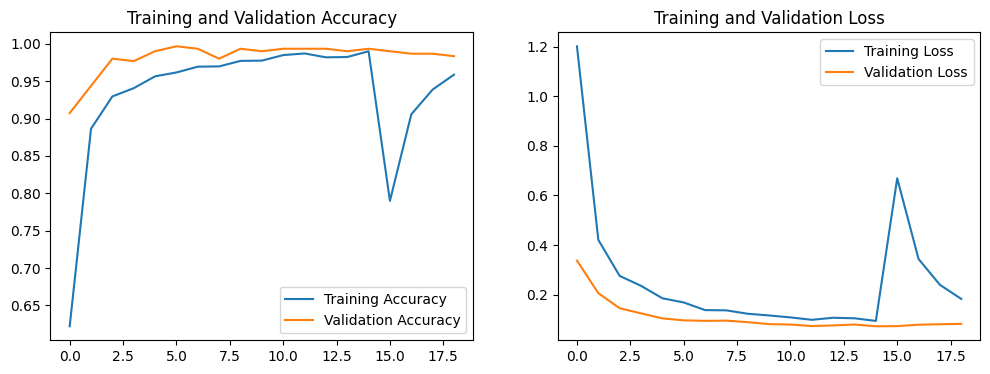

In [78]:
acc = history.history['accuracy'] + fine_tune_history.history['accuracy']
val_acc = history.history['val_accuracy'] + fine_tune_history.history['val_accuracy']
loss = history.history['loss'] + fine_tune_history.history['loss']
val_loss = history.history['val_loss'] + fine_tune_history.history['val_loss']

# acc = history.history['accuracy'] 
# val_acc = history.history['val_accuracy'] 
# loss = history.history['loss'] 
# val_loss = history.history['val_loss'] 


# acc =  fine_tune_history.history['accuracy']
# val_acc = fine_tune_history.history['val_accuracy']
# loss =  fine_tune_history.history['loss']
# val_loss =  fine_tune_history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [79]:
model.save('faruqmobtest3000-1.h5')
model.save('faruqmob3000.keras')

In [ ]:

m1 = '/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/faruq1.h5'
m2 = '/Users/abdulmateen/tensorflow-test/mlproject/segmentation/notebook/faruqmobtest3000-1.h5'
model = tf.keras.models.load_model(m2)
# Register HEIF opener with Pill2w
pillow_heif.register_heif_opener()

def predict_single_image(model, image_path, class_names, target_size=(224, 224), show_image=True):
    """
    Make prediction on a single external image
    
    Args:
        model: Your trained Keras model
        image_path: Path to the image file
        class_names: List of class names (same order as training)
        target_size: Input size expected by model (224, 224)
        show_image: Whether to display the image
    
    Returns:
        predicted_class: Name of predicted class
        confidence: Confidence score (0-1)
        all_predictions: Array of all class probabilities
    """
    try:
        # Load and preprocess the image
        img = Image.open(image_path)
        
        # Convert to RGB if needed (handles HEIC, PNG with transparency, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        
        # Resize to target size
        img = img.resize(target_size)
        
        # Convert to numpy array
        img_array = np.array(img)
        
        # Add batch dimension
        img_array = np.expand_dims(img_array, axis=0)
        
        # Make prediction
        predictions = model.predict(img_array, verbose=0)
        
        # Get the predicted class and confidence
        predicted_class_idx = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_idx]
        predicted_class = class_names[predicted_class_idx]
        
        # Display the image if requested
        if show_image:
            plt.figure(figsize=(8, 6))
            plt.imshow(img)
            plt.title(f'Prediction: {predicted_class} (Confidence: {confidence:.2%})')
            plt.axis('off')
            plt.show()
        
        return predicted_class, confidence, predictions[0]
        
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None, None, None

def predict_multiple_images(model, image_folder, class_names, target_size=(224, 224), show_results=True):
    """
    Make predictions on multiple images in a folder
    
    Args:
        model: Your trained Keras model
        image_folder: Path to folder containing images
        class_names: List of class names
        target_size: Input size expected by model
        show_results: Whether to display results
    
    Returns:
        results: List of dictionaries with results for each image
    """
    results = []
    
    # Get all image files in the folder
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.heic')
    image_files = [f for f in os.listdir(image_folder) 
                   if f.lower().endswith(image_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for i, filename in enumerate(image_files):
        image_path = os.path.join(image_folder, filename)
        print(f"\nProcessing {i+1}/{len(image_files)}: {filename}")
        
        predicted_class, confidence, all_predictions = predict_single_image(
            model, image_path, class_names, target_size, show_image=show_results
        )
        
        if predicted_class is not None:
            result = {
                'filename': filename,
                'predicted_class': predicted_class,
                'confidence': confidence,
                'all_predictions': all_predictions
            }
            results.append(result)
            
            print(f"Prediction: {predicted_class} (Confidence: {confidence:.2%})")
        else:
            print(f"Failed to process {filename}")
    
    return results

def show_top_predictions(predictions, class_names, top_n=3):
    """
    Display top N predictions with their probabilities
    
    Args:
        predictions: Array of prediction probabilities
        class_names: List of class names
        top_n: Number of top predictions to show
    """
    # Get indices of top predictions
    top_indices = np.argsort(predictions)[::-1][:top_n]
    
    print(f"\nTop {top_n} predictions:")
    for i, idx in enumerate(top_indices):
        print(f"{i+1}. {class_names[idx]}: {predictions[idx]:.2%}")

# Example usage functions
def predict_with_your_model(image_path):
    """
    Wrapper function using your specific model and class names
    """
    # Your class names from the training
    class_names = ['Bitterleaf', 'Efirin', 'Ewedu', 'amunututu', 'elegede', 
                   'soko ', 'tete ', 'ugu ', 'uziza leave', 'waterleaf']
    
    # Make prediction
    predicted_class, confidence, all_predictions = predict_single_image(
        model, image_path, class_names, target_size=(224, 224), show_image=True
    )
    
    if predicted_class is not None:
        print(f"\nPredicted class: {predicted_class}")
        print(f"Confidence: {confidence:.2%}")
        
        # Show top 3 predictions
        show_top_predictions(all_predictions, class_names, top_n=3)
    
    return predicted_class, confidence, all_predictions

# Example usage:
# predicted_class, confidence, all_predictions = predict_with_your_model('/path/to/your/image.jpg')

# For batch processing:
# results = predict_multiple_images(model, '/path/to/image/folder', class_names)

Error processing image /path/to/your/image.jpg: [Errno 2] No such file or directory: '/path/to/your/image.jpg'


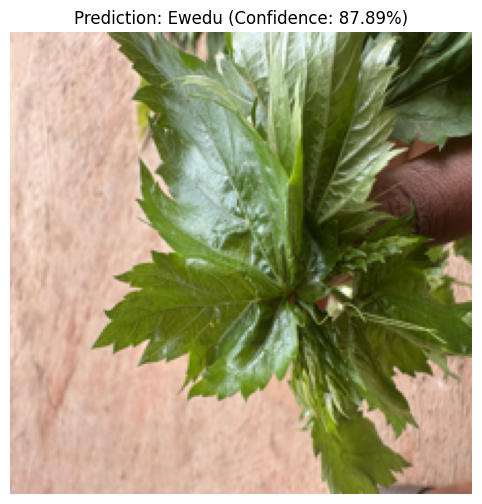


Predicted class: Ewedu
Confidence: 87.89%

Top 3 predictions:
1. Ewedu: 87.89%
2. Efirin: 8.74%
3. waterleaf: 1.27%


In [93]:
predicted_class, confidence, all_predictions = predict_with_your_model('/Users/abdulmateen/Downloads/vegetables/Ewedu/IMG_7261.JPG')


11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 285ms/step


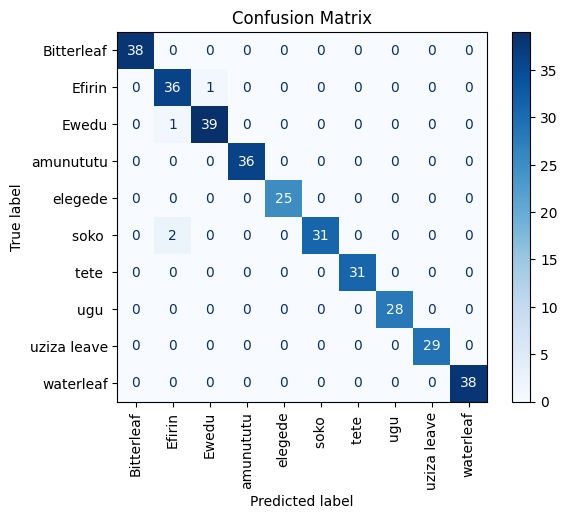

In [ ]:

def plot_confusion_matrix(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    y_pred_labels = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(xticks_rotation='vertical', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()


plot_confusion_matrix(model, test_images, test_labels, class_names)


In [ ]:

def print_classification_report(model, X_test, y_test, class_names):
    y_pred = model.predict(X_test)
    y_pred_labels = y_pred.argmax(axis=1)
    
    print(classification_report(y_test, y_pred_labels, target_names=class_names))


In [84]:

print_classification_report(model, test_images, test_labels, class_names)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step
              precision    recall  f1-score   support

  Bitterleaf       1.00      1.00      1.00        38
      Efirin       0.92      0.97      0.95        37
       Ewedu       0.97      0.97      0.97        40
   amunututu       1.00      1.00      1.00        36
     elegede       1.00      1.00      1.00        25
       soko        1.00      0.94      0.97        33
       tete        1.00      1.00      1.00        31
        ugu        1.00      1.00      1.00        28
 uziza leave       1.00      1.00      1.00        29
   waterleaf       1.00      1.00      1.00        38

    accuracy                           0.99       335
   macro avg       0.99      0.99      0.99       335
weighted avg       0.99      0.99      0.99       335



In [ ]:


def evaluate_model(model, X_test, y_test, class_names):
    # Predict and convert to label indices
    y_pred = model.predict(X_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    # Accuracy score
    acc = accuracy_score(y_test, y_pred_labels)
    print(f"Accuracy: {acc:.4f}\n")

 

evaluate_model(model, test_images, test_labels, class_names)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 269ms/step
Accuracy: 0.9881

